In [54]:
import pennylane as qml
import numpy as np
import torch

In [55]:
seed = 4321
np.random.seed(seed=seed)
torch.manual_seed(seed=seed)

In [56]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

X,y = load_breast_cancer(return_X_y=True)
scaler = MinMaxScaler(feature_range=(0,torch.pi))
X = scaler.fit_transform(X)
x_tr, x_test, y_tr, y_test = train_test_split(X, y, train_size=0.8, shuffle=True)

La base de datos que vamos a emplear tiene 30 variables, y a dia de hoy no tenemos acceso a ordenadores con 30 qubits, por lo que hemos de considerar una de las siguientes opciones: 
1. Usar amplitude encoding como feature map sobre 5 qubits (2**5 = 32)
2. Usar cualquier otro feature map pero con una reduccion de la dimensionalidad

METODO 1: AMPLITUDE ENCODING

METODO 2: REDUCCION DE LA DIMENSIONALIDAD

Vamos a restringir el caso a un circuito de 4 qubits

In [57]:
pca = PCA(n_components=4)
xs_tr = pca.fit_transform(x_tr)
xs_test = pca.transform(x_test)

xs_tr = torch.tensor(xs_tr, dtype=torch.float32)
xs_test = torch.tensor(xs_test, dtype=torch.float32)

y_tr = torch.tensor(y_tr, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)
reps = 5
nqubits = 4

In [58]:
# Vamos a usar ZZ feature map y la forma variacional two-local
from itertools import combinations

def ZZFeatureMap(nqubits, data):


    nload = min(len(data), nqubits)
    for i in range(nload):
        qml.Hadamard(i)
        qml.RZ(2 * data[i], wires = i)
    
    for pair in list(combinations(range(nload),2)):
        q0 = pair[0]
        q1 = pair[1]

        qml.CNOT(wires=[q0, q1])
        qml.RZ(2.0 * (torch.pi-data[q1])*(torch.pi-data[q0]), wires=q1)
        qml.CNOT(wires=[q0, q1])

def TwoLocal(nqubits, theta, reps):
    for r in range(reps):
        for j in range(nqubits):
            qml.RY(theta[r,j], wires=j)
        
        for j in range(nqubits-1):
            qml.CNOT(wires=[j,j+1])
    
    for j in range(nqubits):
        qml.RY(theta[reps,j], wires=j)


In [59]:
nqubits = 4
dev = qml.device('default.qubit', wires=nqubits)

def qnn_circuit(inputs, theta):
    ZZFeatureMap(nqubits=nqubits, data=inputs)
    TwoLocal(nqubits=nqubits, theta=theta, reps=reps) # por simplicidad se pide una repeticion unicamente
    return qml.expval(qml.PauliZ(0))

# se añade el argumento interface = 'torch' al inicializar el nodo para que trabaje con pytorch
qnn = qml.QNode(qnn_circuit, dev, interface='torch')

theta = torch.randn((reps+1, nqubits), requires_grad=True)

In [60]:
class QNN(torch.nn.Module):
    def __init__(self, nqubits=4, reps=5):
        super().__init__()
        self.nqubits = nqubits
        self.reps = reps

        self.weights = torch.nn.Parameter(
            torch.randn((reps + 1, nqubits))
        )

    def forward(self, x):
        return qnn(x, self.weights)

In [61]:
# estamos creado un circuito cuantico pero con pytorch podremos hallar 
# su gradiente para poder entrenarlo

# incluimos una capa clasica antes del circuito que incluye 2 neuronas
# y otra tras el circuito que incluye 2 neuronas tambien
model = QNN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
criterion = torch.nn.BCELoss()

In [62]:
losses = []

In [64]:
epochs = 10

for epoch in range(epochs):

    optimizer.zero_grad()

    y_pred = torch.stack([model(x) for x in xs_tr])
    print(y_pred.dtype, y_tr.dtype)
    loss = criterion(y_pred, y_tr)

    print(f'Epoch: {epoch} and loss: {loss.item()}')
    
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

torch.float64 torch.float32


RuntimeError: Found dtype Float but expected Double

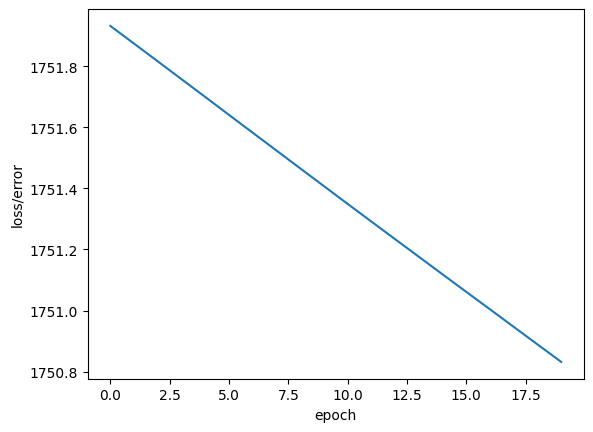

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(len(losses)),losses)
plt.ylabel('loss/error')
plt.xlabel('epoch')
plt.show()

In [ ]:
def predict(model, X, threshold=0.5):
    preds = []
    for x in X:
        out = model(x)
        preds.append((out > threshold).float())
    return torch.stack(preds).squeeze()

In [ ]:
y_pred = predict(model, xs_test)
correct = [1 if p == p_true else 0 for p, p_true in zip(y_pred, y_test)]
accuracy = sum(correct) / len(correct)
print(f"Accuracy: {accuracy * 100}%")

Accuracy: 46.49122807017544%
